In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics:")
print(df.describe(include="all"))

Shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0

Summary Statistics:
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1  

The dataset contains missing values in several columns such as Age, Cabin, and Embarked. No major duplicate records were found.

In [4]:
before_rows = df.shape[0]
before_nulls = df.isnull().sum().sum()
before_duplicates = df.duplicated().sum()
before_dtypes = df.dtypes

In [5]:
# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it has many missing values
df.drop(columns=["Cabin"], inplace=True)

Missing values in Age were filled using the median because it is less affected by outliers. Embarked was filled with the most frequent value (mode). The Cabin column was removed due to a high percentage of missing values.

In [6]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicates Removed:", duplicates_before - duplicates_after)

Duplicates Removed: 0


In [7]:
# Standardize Gender values
df["Sex"] = df["Sex"].replace({
    "male": "Male",
    "female": "Female"
})

# Convert Name to title case
df["Name"] = df["Name"].str.title()

In [8]:
df["PassengerId"] = df["PassengerId"].astype(str)

PassengerId is an identifier rather than a numeric value, so it was converted to string.

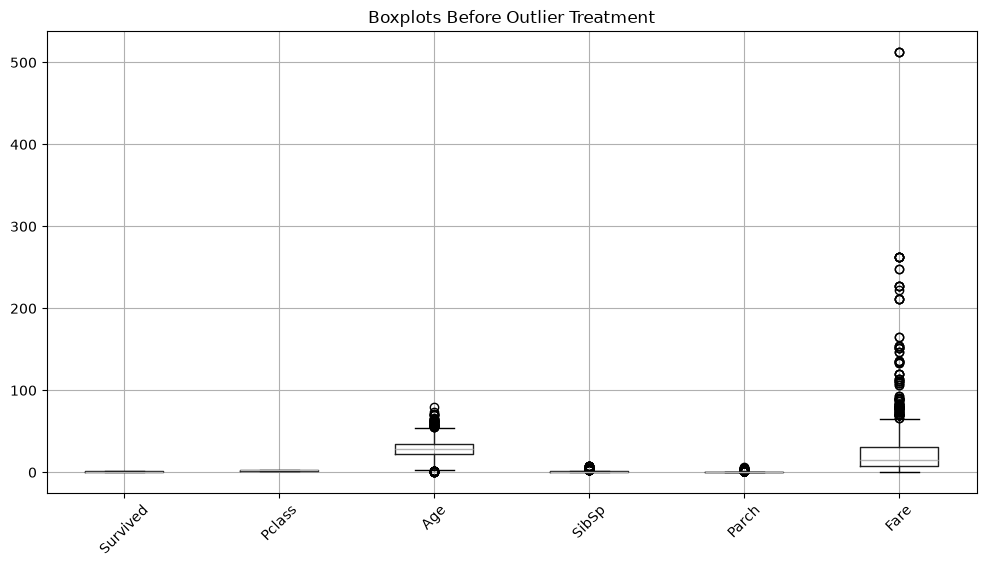

In [9]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Plot boxplots before handling outliers
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplots Before Outlier Treatment")
plt.show()

In [10]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

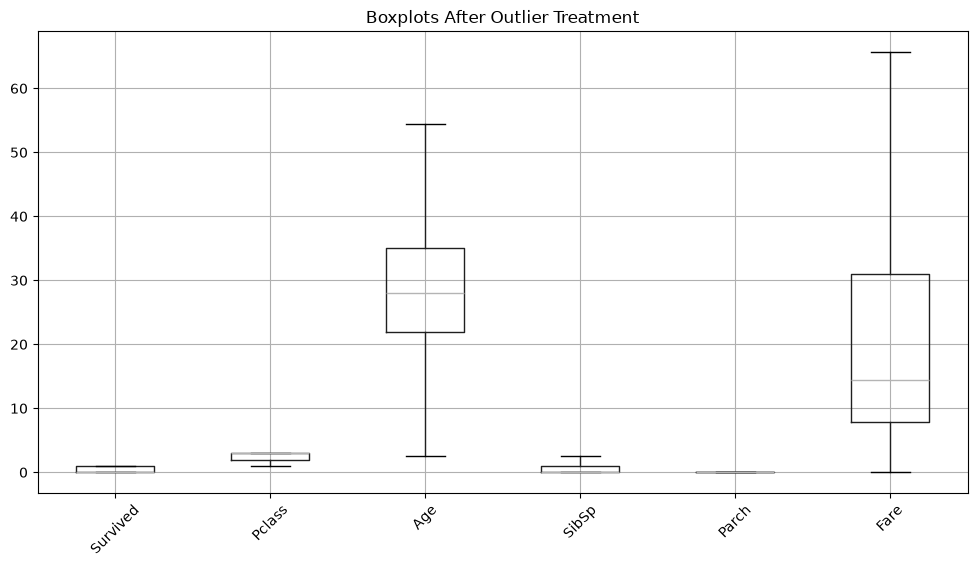

In [11]:
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplots After Outlier Treatment")
plt.show()

Outliers were detected using the IQR method and capped at the lower and upper limits instead of removing rows, preserving the dataset size.

In [12]:
after_rows = df.shape[0]
after_nulls = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

summary = pd.DataFrame({
    "Metric": ["Rows", "Missing Values", "Duplicate Rows"],
    "Before Cleaning": [before_rows, before_nulls, before_duplicates],
    "After Cleaning": [after_rows, after_nulls, after_duplicates]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Rows,891,891
1,Missing Values,866,0
2,Duplicate Rows,0,0


In [13]:
df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


Data Quality Report
Missing Values
Boxplot Before Cleaning
Boxplot After Cleaning
Before vs After Summary

In [14]:
plt.savefig("screenshots/Data_Quality_Report.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

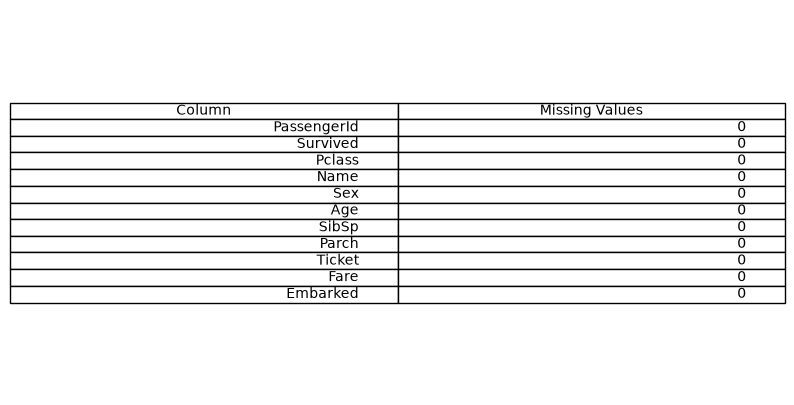

In [15]:
fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
table = ax.table(
    cellText=df.isnull().sum().reset_index().values,
    colLabels=["Column", "Missing Values"],
    loc='center'
)

plt.savefig("screenshots/data_quality.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

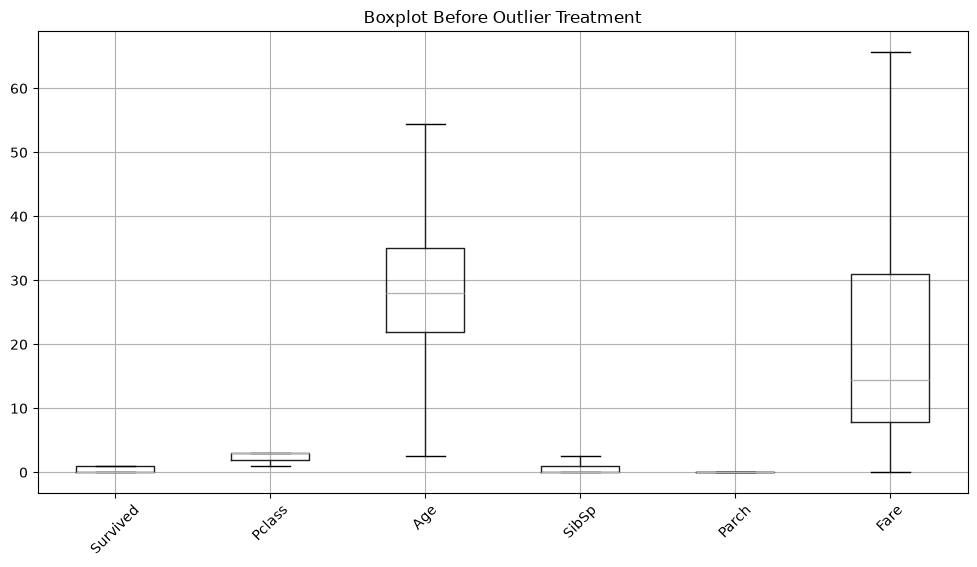

In [16]:
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot Before Outlier Treatment")

plt.savefig("screenshots/boxplot_before.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

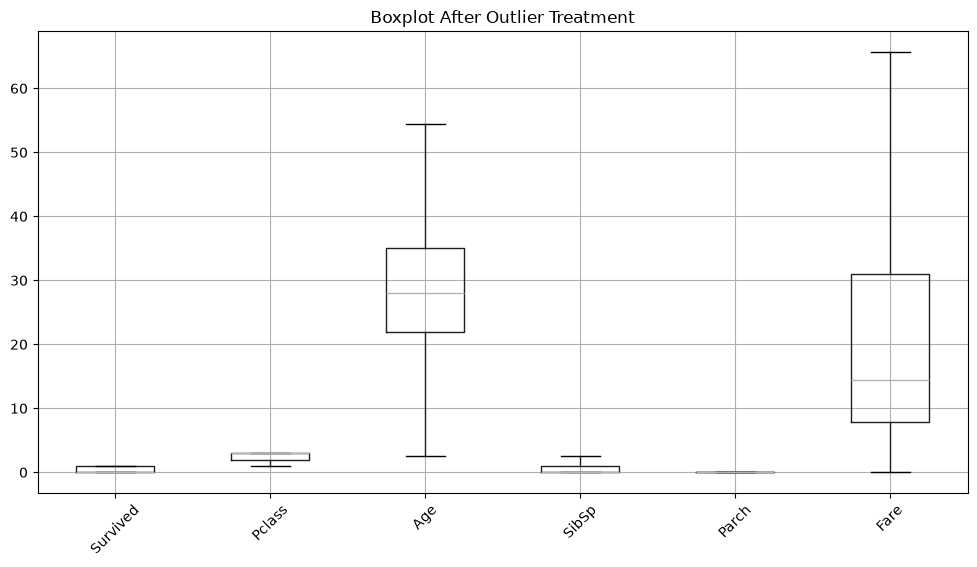

In [17]:
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot After Outlier Treatment")

plt.savefig("screenshots/boxplot_after.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

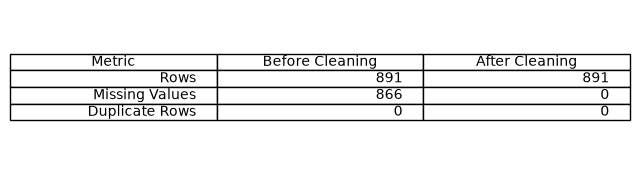

In [18]:
fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    loc='center'
)

plt.savefig("screenshots/summary.png",
            dpi=300,
            bbox_inches="tight")

plt.show()